# Divar Real Estate Analysis — Recommender System (Clustering)

**Section 3 (machine learning), problem 1.** One recommender system, answered in the three parts the question asks for: feature choice with KMeans (k=10), choosing the number of clusters, and DBSCAN

**Author:** Mahdi Tarrah

**Data:** `data/Divar.csv`

## Data Preparation

In [1]:
# libraries

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import utm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore',category=UserWarning,module='sklearn')

In [2]:
# load data

clustering_columns = ['price_value','building_size','rooms_count','location_latitude','location_longitude','cat2_slug','cat3_slug','city_slug','construction_year', 'has_parking', 'has_elevator']
df = pd.read_csv('../data/Divar.csv', usecols=clustering_columns)
print(df.shape)
df.head()

(1000000, 11)


,cat2_slug,cat3_slug,city_slug,price_value,building_size,rooms_count,has_elevator,has_parking,construction_year,location_latitude,location_longitude
0,temporary-rent,villa,karaj,NaN,500.0,سه,NaN,NaN,NaN,35.811684,50.936600
1,residential-sell,apartment-sell,tehran,8.500000e+09,60.0,یک,True,True,۱۳۸۴,NaN,NaN
2,residential-rent,apartment-rent,tehran,NaN,132.0,سه,True,True,۱۴۰۱,35.703865,51.373459
3,commercial-rent,office-rent,tehran,NaN,90.0,یک,True,True,۱۴۰۰,NaN,NaN
4,residential-sell,apartment-sell,mashhad,5.750000e+09,115.0,دو,True,True,۱۴۰۳,NaN,NaN


In [3]:
# null check

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   cat2_slug           1000000 non-null  str    
 1   cat3_slug           999999 non-null   str    
 2   city_slug           999998 non-null   str    
 3   price_value         568346 non-null   float64
 4   building_size       980394 non-null   float64
 5   rooms_count         845899 non-null   str    
 6   has_elevator        541749 non-null   object 
 7   has_parking         728156 non-null   object 
 8   construction_year   815828 non-null   str    
 9   location_latitude   655608 non-null   float64
 10  location_longitude  655608 non-null   float64
dtypes: float64(4), object(2), str(5)
memory usage: 83.9+ MB


In [4]:
# cleaning

data = df.copy()

data.loc[data['price_value'] <= 0,'price_value'] = np.nan

def clean_outliers(data,column):
    logs = np.log(data[column])
    q1, q3 = logs.quantile(0.25),logs.quantile(0.75)
    iqr = q3 - q1
    data.loc[~logs.between(q1-1.5*iqr,q3 +1.5*iqr),column] = np.nan
    return data

data = clean_outliers(data,'price_value')
data = clean_outliers(data,'building_size')

inside_iran = (data['location_latitude'].between(25,40)) & (data['location_longitude'].between(44,63.5))
data.loc[~inside_iran,['location_latitude','location_longitude']] = np.nan

data = data.dropna(subset=['building_size','price_value','location_latitude','location_longitude'])

print(data.shape)
print(data[['price_value','building_size']].describe())

(324485, 11)
        price_value  building_size
count  3.244850e+05  324485.000000
mean   5.047053e+09     130.622852
std    6.172471e+09      87.705984
min    1.640000e+08      23.000000
25%    1.600000e+09      75.000000
50%    3.000000e+09     100.000000
75%    5.850000e+09     153.000000
max    5.100000e+10     538.000000


In [5]:
# to UTM

xy = [utm.from_latlon(lat,lon,force_zone_number=39)[:2] for lat,lon in zip(data['location_latitude'], data['location_longitude'])]

data['utm_x'] = [p[0] for p in xy]
data['utm_y'] = [p[1] for p in xy]

print(data[['utm_x','utm_y']].describe())

              utm_x         utm_y
count  3.244850e+05  3.244850e+05
mean   5.549497e+05  3.888984e+06
std    2.790465e+05  2.525020e+05
min   -1.146343e+05  2.803746e+06
25%    4.763461e+05  3.860848e+06
50%    5.304762e+05  3.953651e+06
75%    5.738981e+05  4.042502e+06
max    1.660176e+06  4.407134e+06


In [6]:
# zone check

print(((data['utm_x'] < 100000) | (data['utm_x'] > 900000)).sum())

51619


In [7]:
# rooms to number

rooms_mapping = {'بدون اتاق':0,'یک':1,'دو':2,'سه':3,'چهار':4,'پنج یا بیشتر':5}
data['rooms_count'] = data['rooms_count'].map(rooms_mapping)

## Part 1 — Feature Selection and KMeans with 10 Clusters

### Choosing the feature set

In [8]:
# year to number

digits = str.maketrans('۰۱۲۳۴۵۶۷۸۹','0123456789')
year = data['construction_year'].replace('قبل از ۱۳۷۰', '۱۳۶۹')
data['construction_year'] = pd.to_numeric(year.str.translate(digits), errors='coerce')
print(data['construction_year'].describe())

count    275148.000000
mean       1394.260892
std           8.411427
min        1369.000000
25%        1390.000000
50%        1396.000000
75%        1402.000000
max        1403.000000
Name: construction_year, dtype: float64


In [9]:
# common subset

data_cmp = data.dropna(subset=['rooms_count','construction_year'])
print(data.shape, data_cmp.shape)

(324485, 13) (275143, 13)


In [10]:
# feature correlation

print(data_cmp[['price_value','building_size','rooms_count','construction_year']].corr())

                   price_value  building_size  rooms_count  construction_year
price_value           1.000000       0.398886     0.344050          -0.026310
building_size         0.398886       1.000000     0.617901           0.090851
rooms_count           0.344050       0.617901     1.000000           0.116831
construction_year    -0.026310       0.090851     0.116831           1.000000


In [11]:
# compare feature sets

feature_sets = {'A: price + utm + size': ['price_value','utm_x','utm_y','building_size'],'B: A + rooms':['price_value','utm_x','utm_y','building_size','rooms_count'],'C: price + utm':['price_value','utm_x','utm_y'],'D: C + year': ['price_value','utm_x','utm_y','construction_year']}

rows = []

for name, feats in feature_sets.items():
    X = StandardScaler().fit_transform(data_cmp[feats])
    km = KMeans(10, random_state=44)
    labels = km.fit_predict(X)
    rows.append({'feature set': name,
                 'silhouette (higher is better)': silhouette_score(X, labels, sample_size=10000, random_state=44),
                 'calinski (higher is better)': calinski_harabasz_score(X, labels),
                 'davies (lower is better)': davies_bouldin_score(X, labels)})

pd.DataFrame(rows).set_index('feature set').round(3)

,silhouette (higher is better),calinski (higher is better),davies (lower is better)
feature set,,,
A: price + utm + size,0.381,102768.064,1.029
B: A + rooms,0.344,74908.885,1.088
C: price + utm,0.476,186268.201,0.751
D: C + year,0.329,94459.929,0.992


<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>All three metrics pick price + coordinates</li>
<li>Every extra feature made the clusters worse</li>
<li>Dropped rooms (same information as size) and year (no link to price)</li>
</ul>
</font></div>

### KMeans with 10 clusters

In [12]:
# KMeans k=10

scaler = StandardScaler()
X = scaler.fit_transform(data[['price_value','utm_x','utm_y']])

km = KMeans(10, random_state=44)
data['cluster'] = km.fit_predict(X)

print(data['cluster'].value_counts().sort_index())

cluster
0    137901
1     15432
2     14367
3     24922
4     29346
5     24057
6     10223
7     20049
8     42856
9      5332
Name: count, dtype: int64


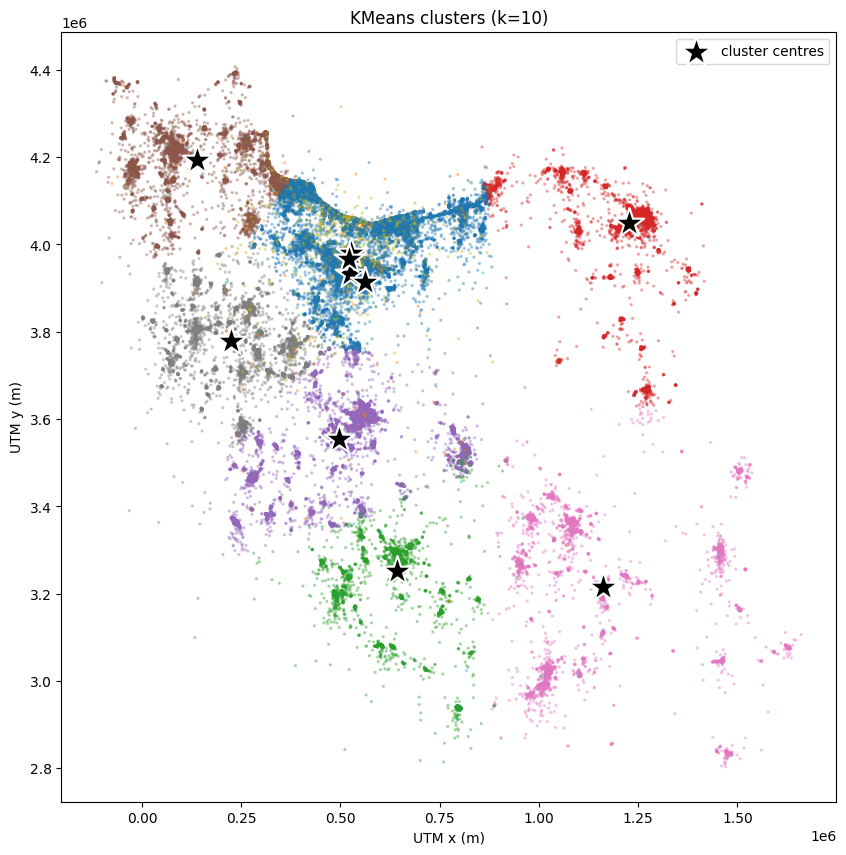

In [13]:
# cluster map

centers = scaler.inverse_transform(km.cluster_centers_)

plt.figure(figsize=(10, 10))
plt.scatter(data['utm_x'],data['utm_y'],c=data['cluster'],s=2,alpha=0.3,cmap='tab10')
plt.scatter(centers[:, 1],centers[:, 2], marker='*',c='black',s=500,edgecolors='white',linewidths=1.5,zorder=5,label='cluster centres')
plt.xlabel('UTM x (m)')
plt.ylabel('UTM y (m)')
plt.title('KMeans clusters (k=10)')
plt.legend()
plt.show()

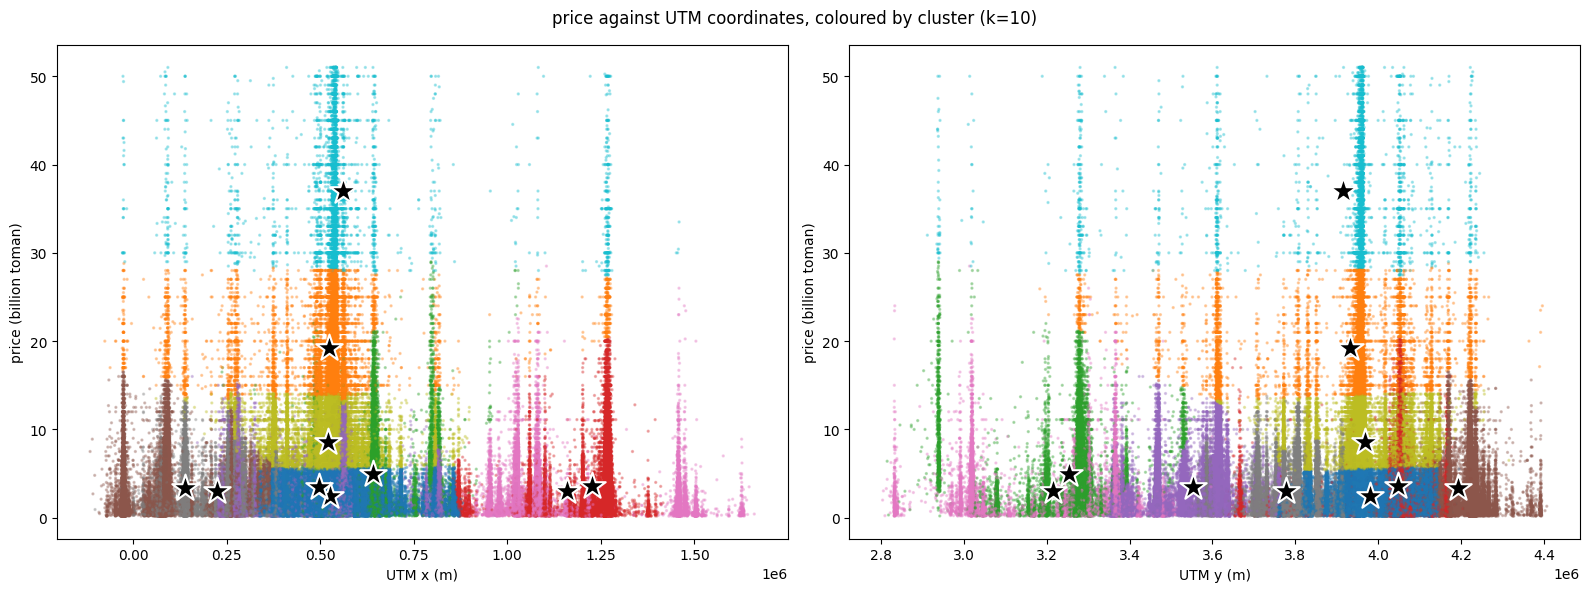

In [14]:
# price scatter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(data['utm_x'],data['price_value']/1e9,c=data['cluster'], s=2, alpha=0.3,cmap='tab10')
axes[0].scatter(centers[:, 1], centers[:, 0]/1e9,marker='*',c='black',s=400,edgecolors='white',linewidths=1.5,zorder=5)
axes[0].set_xlabel('UTM x (m)')
axes[0].set_ylabel('price (billion toman)')

axes[1].scatter(data['utm_y'],data['price_value']/1e9,c=data['cluster'],s=2,alpha=0.3, cmap='tab10')
axes[1].scatter(centers[:, 2],centers[:, 0]/1e9,marker='*',c='black',s=400,edgecolors='white',linewidths=1.5,zorder=5)
axes[1].set_xlabel('UTM y (m)')
axes[1].set_ylabel('price (billion toman)')

plt.suptitle('price against UTM coordinates, coloured by cluster (k=10)')
plt.tight_layout()
plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>The question asks for a scatter plot of price against the UTM coordinates, so this is that plot, while the previous one is the same clustering seen as a map</li>
<li>Every point is coloured by its cluster and the black stars are the cluster centres</li>
<li>It shows what the map cannot: inside Tehran the clusters are separated by price, not by location</li>
</ul>
</font></div>

In [15]:
# cluster profile

profile = data.groupby('cluster').agg(n=('cluster','size'),price_M=('price_value', lambda s: round(s.median()/1e6)),size_m2=('building_size','median'))
profile['top_cities'] = data.groupby('cluster')['city_slug'].apply(lambda s: ','.join(s.value_counts().head(3).index))
print(profile.sort_values('price_M'))

              n  price_M  size_m2                      top_cities
cluster                                                          
6         10223     2190    145.0     kerman,bandar-abbas,zahedan
0        137901     2300     85.0  tehran,karaj,andisheh-new-town
7         20049     2450    110.0         kermanshah,hamedan,arak
5         24057     2500    110.0            tabriz,urmia,ardabil
3         24922     2600    108.0       mashhad,neyshabur,bojnurd
4         29346     2800    120.0              isfahan,ahvaz,yazd
2         14367     3700    130.0            shiraz,sadra,bushehr
8         42856     8000    107.0              tehran,karaj,rasht
1         15432    18360    145.0            tehran,isfahan,karaj
9          5332    35200    195.0          tehran,mashhad,isfahan


<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Centres converted back to metres, otherwise they miss their place</li>
<li>Far cities each form their own cluster</li>
<li>Tehran splits into four price levels, which is the recommender logic</li>
</ul>
</font></div>

## Part 2 — Choosing the Number of Clusters

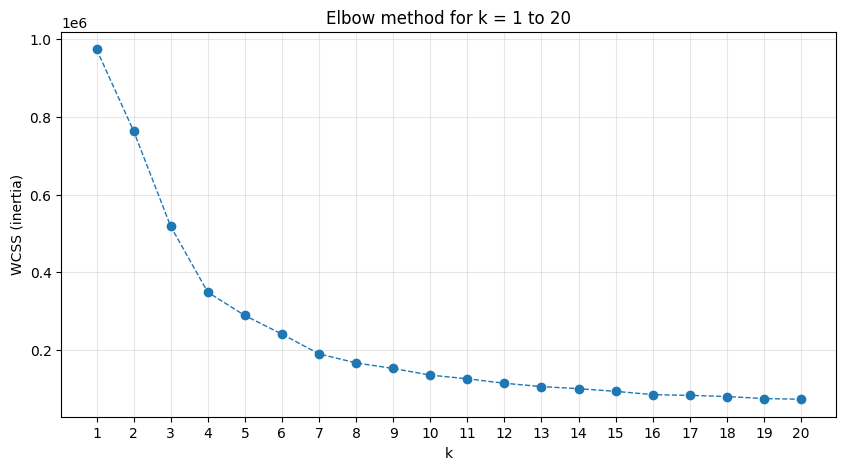

In [16]:
# elbow curve

res = []

for k in range(1, 21):
    km = KMeans(k,random_state=44)
    km.fit(X)
    res.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21),res,marker='o',markersize=6,linestyle='--',linewidth=1)
plt.xticks(range(1, 21))
plt.grid(alpha=0.3)
plt.xlabel('k')
plt.ylabel('WCSS (inertia)')
plt.title('Elbow method for k = 1 to 20')
plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>The knee is not visible by eye</li>
<li>KneeLocator returned 7</li>
</ul>
</font></div>

In [17]:
# find knee

loc = KneeLocator(range(1, 21),res,curve='convex',direction='decreasing')
print(loc.elbow,loc.knee)

7 7


In [18]:
# three metrics

sil, cal, dav = [], [], []

for k in range(2,21):
    km = KMeans(k,random_state=44)
    labels = km.fit_predict(X)
    sil.append( silhouette_score(X,labels,sample_size=10000,random_state=44))
    cal.append(calinski_harabasz_score(X,labels))
    dav.append(davies_bouldin_score(X,labels))

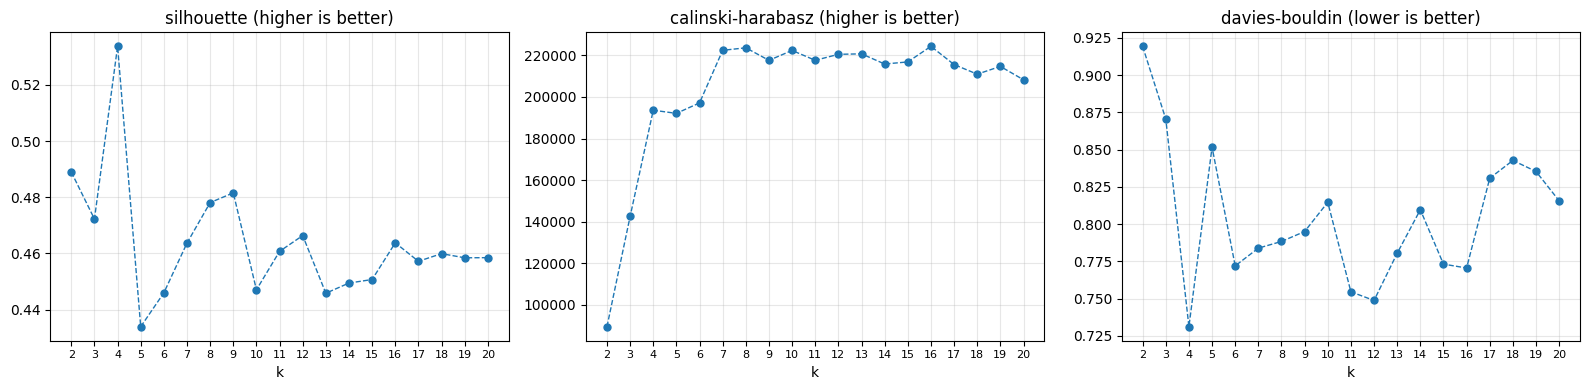

In [19]:
# metric plots

fig, axes = plt.subplots(1,3,figsize=(16,4))

axes[0].plot(range(2,21),sil,marker='o',markersize=5,linestyle='--',linewidth=1)
axes[0].set_title('silhouette (higher is better)')

axes[1].plot(range(2,21),cal,marker='o',markersize=5,linestyle='--',linewidth=1)
axes[1].set_title('calinski-harabasz (higher is better)')

axes[2].plot(range(2,21),dav,marker='o',markersize=5,linestyle='--',linewidth=1)
axes[2].set_title('davies-bouldin (lower is better)')

for ax in axes:
    ax.set_xlabel('k')
    ax.set_xticks(range(2,21))
    ax.tick_params(axis='x',labelsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Silhouette and Davies favour k = 4</li>
<li>Calinski flattens after 7, like the elbow</li>
<li>Silhouette uses a 10k sample, so its curve is jagged</li>
</ul>
</font></div>

In [20]:
# compare k

for k in [4, 7]:
    km_test = KMeans(k,random_state=44)
    labels_test = km_test.fit_predict(X)

    tmp = data.copy()
    tmp['c'] = labels_test

    prof = tmp.groupby('c').agg(n=('c','size'),price_M=('price_value',lambda s: round(s.median() / 1e6)),size_m2=('building_size','median'))
    prof['top_cities'] = tmp.groupby('c')['city_slug'].apply(lambda s: ','.join(s.value_counts().head(3).index))

    print(f'k = {k}')
    print(prof.sort_values('price_M'))
    print()

k = 4
        n  price_M  size_m2                      top_cities
c                                                          
0   26385     2500    110.0       mashhad,neyshabur,bojnurd
3  222405     2800     92.0  tehran,karaj,andisheh-new-town
2   54348     2900    125.0            isfahan,shiraz,ahvaz
1   21347    20700    155.0            tehran,isfahan,karaj

k = 7
        n  price_M  size_m2                      top_cities
c                                                          
6   11564     2300    138.0     kerman,bandar-abbas,zahedan
5   46039     2500    109.0         tabriz,rasht,kermanshah
0  151455     2550     85.0  tehran,karaj,andisheh-new-town
4   25232     2600    108.0       mashhad,neyshabur,bojnurd
2   45765     2960    123.0            isfahan,shiraz,ahvaz
3   35300    12000    120.0            tehran,karaj,isfahan
1    9130    30000    180.0          tehran,mashhad,isfahan



<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>With k = 4 two thirds of the data lands in one cluster</li>
<li>With k = 7 Tehran gets three price levels and cities separate</li>
<li>Chose 7</li>
</ul>
</font></div>

In [21]:
# final KMeans

km_final = KMeans(7, random_state=44)
data['cluster_final'] = km_final.fit_predict(X)

centers_final = scaler.inverse_transform(km_final.cluster_centers_)

print(data['cluster_final'].value_counts().sort_index())

cluster_final
0    151455
1      9130
2     45765
3     35300
4     25232
5     46039
6     11564
Name: count, dtype: int64


In [22]:
# plot range

x_lo, x_hi = data['utm_x'].quantile([0.001, 0.999])
y_lo, y_hi = data['utm_y'].quantile([0.001, 0.999])
inside = ((centers_final[:, 1].clip(x_lo, x_hi) == centers_final[:, 1]) & (centers_final[:, 2].clip(y_lo, y_hi) == centers_final[:, 2]))

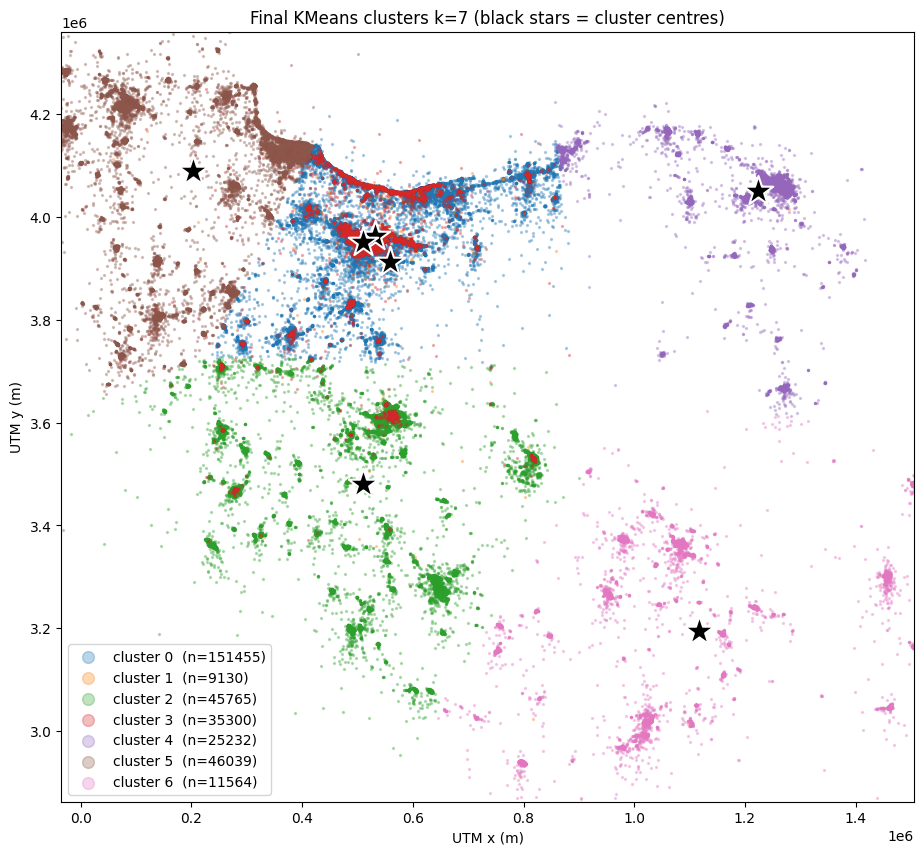

In [23]:
# final map

plt.figure(figsize=(11, 10))

for c in sorted(data['cluster_final'].unique()):
    sub = data[data['cluster_final'] == c]
    plt.scatter(sub['utm_x'], sub['utm_y'], s=2, alpha=0.3, label=f'cluster {c}  (n={len(sub)})')

plt.scatter(centers_final[inside, 1],centers_final[inside, 2],marker='*',c='black',s=500,edgecolors='white',linewidths=1.5,zorder=5)
plt.xlim(x_lo, x_hi)
plt.ylim(y_lo, y_hi)
plt.xlabel('UTM x (m)')
plt.ylabel('UTM y (m)')
plt.title('Final KMeans clusters k=7 (black stars = cluster centres)')
plt.legend(markerscale=6)
plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>One centre falls outside the drawn range</li>
<li>A centre lives in 3D (price and x, y) but only 2D is plotted</li>
</ul>
</font></div>

## Part 3 — DBSCAN

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>The question asks for the transformable price, but in the data that column only holds True and False, so it is a flag saying the ad's credit and rent can be converted, not a price</li>
<li>transformable_credit equals credit_value and transformable_rent equals rent_value, so there is no ready-made unified price column in the dataset</li>
<li>The mentor confirmed using price_value, so this part clusters the sale price together with the UTM coordinates, exactly the two features the question names</li>
</ul>
</font></div>

In [24]:
# sample and scale

data_db = data.sample(100000, random_state=44)

scaler_db = StandardScaler()
X_db = scaler_db.fit_transform(data_db[['price_value','utm_x','utm_y']])

print(X_db.shape)

(100000, 3)


knee index: 99828  eps = 0.642891079483575


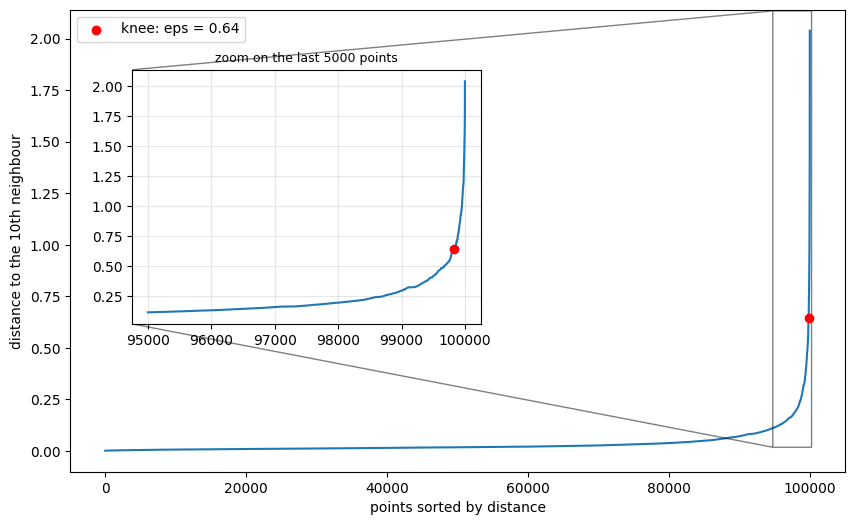

In [25]:
# k-distance eps

nn = NearestNeighbors(n_neighbors=10)
nn.fit(X_db)
neigh_dist, _ = nn.kneighbors()

best_dist = neigh_dist[:,-1]
sorted_dist = np.sort(best_dist)

loc = KneeLocator(range(len(sorted_dist)),sorted_dist,curve='convex')
print('knee index:',loc.knee,' eps =',sorted_dist[loc.knee])

zoom_from = len(sorted_dist) - 5000

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(sorted_dist)),sorted_dist)
ax.scatter(loc.knee, sorted_dist[loc.knee],c='red',zorder=5,label=f'knee: eps = {sorted_dist[loc.knee]:.2f}')
ax.set_xlabel('points sorted by distance')
ax.set_ylabel('distance to the 10th neighbour')
ax.legend(loc='upper left')

axin = ax.inset_axes([0.08, 0.32, 0.45, 0.55])
axin.plot(range(zoom_from, len(sorted_dist)), sorted_dist[zoom_from:])
axin.scatter(loc.knee, sorted_dist[loc.knee], c='red', zorder=5)
axin.set_title(f'zoom on the last {len(sorted_dist) - zoom_from} points', fontsize=9)
axin.grid(alpha=0.3)
ax.indicate_inset_zoom(axin, edgecolor='black')

plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>The k-distance knee gave eps = 0.64</li>
<li>Too large, almost everything became one cluster</li>
</ul>
</font></div>

In [26]:
# first run

db = DBSCAN(eps=0.643,min_samples=10,n_jobs=2)
labels_db = db.fit_predict(X_db)

print(np.unique(labels_db,return_counts=True))

(array([-1,  0,  1]), array([   73, 99913,    14]))


In [27]:
# eps effect

for eps in [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]:
    db = DBSCAN(eps=eps,min_samples=10,n_jobs=2)
    lab = db.fit_predict(X_db)
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    noise = (lab == -1).mean() * 100
    print(f'eps={eps}  clusters={n_clusters}  noise={noise:.1f}%')

eps=0.05  clusters=222  noise=10.3%
eps=0.1  clusters=103  noise=3.7%
eps=0.15  clusters=51  noise=1.9%
eps=0.2  clusters=22  noise=1.1%
eps=0.3  clusters=10  noise=0.6%
eps=0.4  clusters=7  noise=0.3%
eps=0.5  clusters=3  noise=0.1%


In [28]:
# min_samples effect

for ms in [5, 10, 50, 100, 500]:
    db = DBSCAN(eps=0.5,min_samples=ms,n_jobs=2)
    lab = db.fit_predict(X_db)
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    noise = (lab == -1).mean() * 100
    print(f'min_samples={ms}  clusters={n_clusters}  noise={noise:.1f}%')

min_samples=5  clusters=4  noise=0.1%
min_samples=10  clusters=3  noise=0.1%
min_samples=50  clusters=2  noise=0.6%
min_samples=100  clusters=1  noise=1.2%
min_samples=500  clusters=2  noise=4.2%


In [29]:
# grid search

for eps in [0.3,0.35,0.4,0.45]:
    for ms in [1000,1500,2000,3000]:
        db = DBSCAN(eps=eps,min_samples=ms,n_jobs=2)
        lab = db.fit_predict(X_db)
        n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
        sizes = sorted(np.bincount(lab[lab >= 0]).tolist(),reverse=True) if n_clusters else []
        noise = (lab == -1).mean() * 100
        print(f'eps={eps}  ms={ms}  clusters={n_clusters}  noise={noise:4.1f}%  sizes={sizes[:4]}')

eps=0.3  ms=1000  clusters=8  noise=22.0%  sizes=[57334, 5632, 4639, 3411]
eps=0.3  ms=1500  clusters=5  noise=29.9%  sizes=[55521, 5341, 4423, 2969]
eps=0.3  ms=2000  clusters=3  noise=36.0%  sizes=[54684, 5160, 4161]
eps=0.3  ms=3000  clusters=2  noise=43.1%  sizes=[52282, 4611]
eps=0.35  ms=1000  clusters=5  noise=14.7%  sizes=[69839, 6100, 3881, 2970]
eps=0.35  ms=1500  clusters=6  noise=23.8%  sizes=[57691, 5832, 4686, 3561]
eps=0.35  ms=2000  clusters=4  noise=29.9%  sizes=[56815, 5599, 4514, 3189]
eps=0.35  ms=3000  clusters=3  noise=36.5%  sizes=[54664, 5078, 3784]
eps=0.4  ms=1000  clusters=4  noise=12.1%  sizes=[75347, 6314, 3539, 2702]
eps=0.4  ms=1500  clusters=6  noise=15.9%  sizes=[69108, 6127, 3748, 2932]
eps=0.4  ms=2000  clusters=5  noise=24.1%  sizes=[59031, 5973, 4757, 3699]
eps=0.4  ms=3000  clusters=3  noise=32.8%  sizes=[57469, 5514, 4248]
eps=0.45  ms=1000  clusters=3  noise=10.0%  sizes=[79656, 6694, 3660]
eps=0.45  ms=1500  clusters=3  noise=12.2%  sizes=[77871

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Larger eps means fewer clusters and less noise</li>
<li>Larger min_samples means more noise</li>
</ul>
</font></div>

In [30]:
# final DBSCAN

db_final = DBSCAN(eps=0.45,min_samples=1000,n_jobs=2)
data_db['dbscan'] = db_final.fit_predict(X_db)
print(np.unique(data_db['dbscan'],return_counts=True))

(array([-1,  0,  1,  2]), array([ 9990, 79656,  6694,  3660]))


In [31]:
# DBSCAN profile

prof_db = data_db[data_db['dbscan'] >= 0].groupby('dbscan').agg(n=('dbscan', 'size'),price_M=('price_value', lambda s: round(s.median() / 1e6)),size_m2=('building_size','median'),)
prof_db['top_cities'] = data_db[data_db['dbscan'] >= 0].groupby('dbscan')['city_slug'].apply(lambda s: ','.join(s.value_counts().head(4).index))
print(prof_db)

noise = data_db[data_db['dbscan'] == -1]
print('noise count:',len(noise))
print('noise median price:',round(noise['price_value'].median()/1e6),'M')
print('noise top cities:',noise['city_slug'].value_counts().head(4).index.tolist())

            n  price_M  size_m2                               top_cities
dbscan                                                                  
0       79656     2900     97.0   tehran,karaj,andisheh-new-town,isfahan
1        6694     2580    103.0  mashhad,neyshabur,bojnurd,golbahar-city
2        3660     2900    126.0               shiraz,sadra,yasuj,bushehr
noise count: 9990
noise median price: 9200 M
noise top cities: ['tehran', 'kerman', 'bandar-abbas', 'yazd']


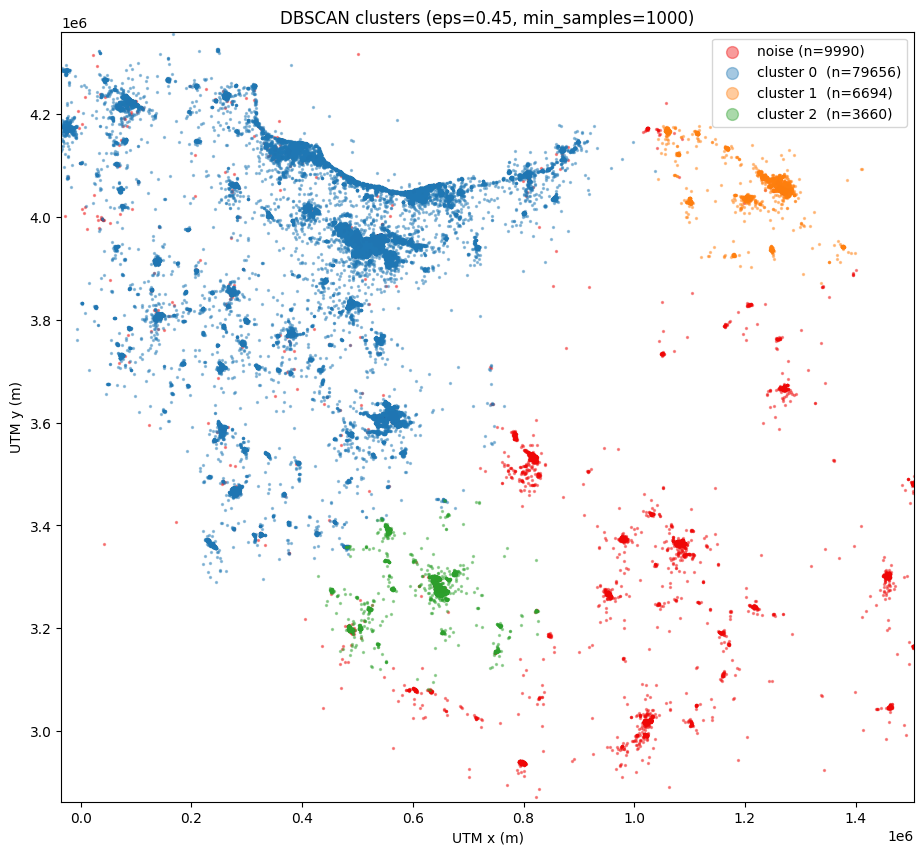

In [32]:
# DBSCAN map

plt.figure(figsize=(11, 10))

noise_mask = data_db['dbscan'] == -1

plt.scatter(data_db.loc[noise_mask,'utm_x'],data_db.loc[noise_mask,'utm_y'],s=2,alpha=0.4,c="#EF0707",label=f'noise (n={noise_mask.sum()})')

for c in sorted(data_db.loc[~noise_mask,'dbscan'].unique()):
    sub = data_db[data_db['dbscan'] == c]
    plt.scatter(sub['utm_x'],sub['utm_y'],s=2,alpha=0.4,label=f'cluster {c}  (n={len(sub)})')

plt.xlim(x_lo,x_hi)
plt.ylim(y_lo,y_hi)
plt.xlabel('UTM x (m)')
plt.ylabel('UTM y (m)')
plt.title('DBSCAN clusters (eps=0.45, min_samples=1000)')
plt.legend(markerscale=6)
plt.show()

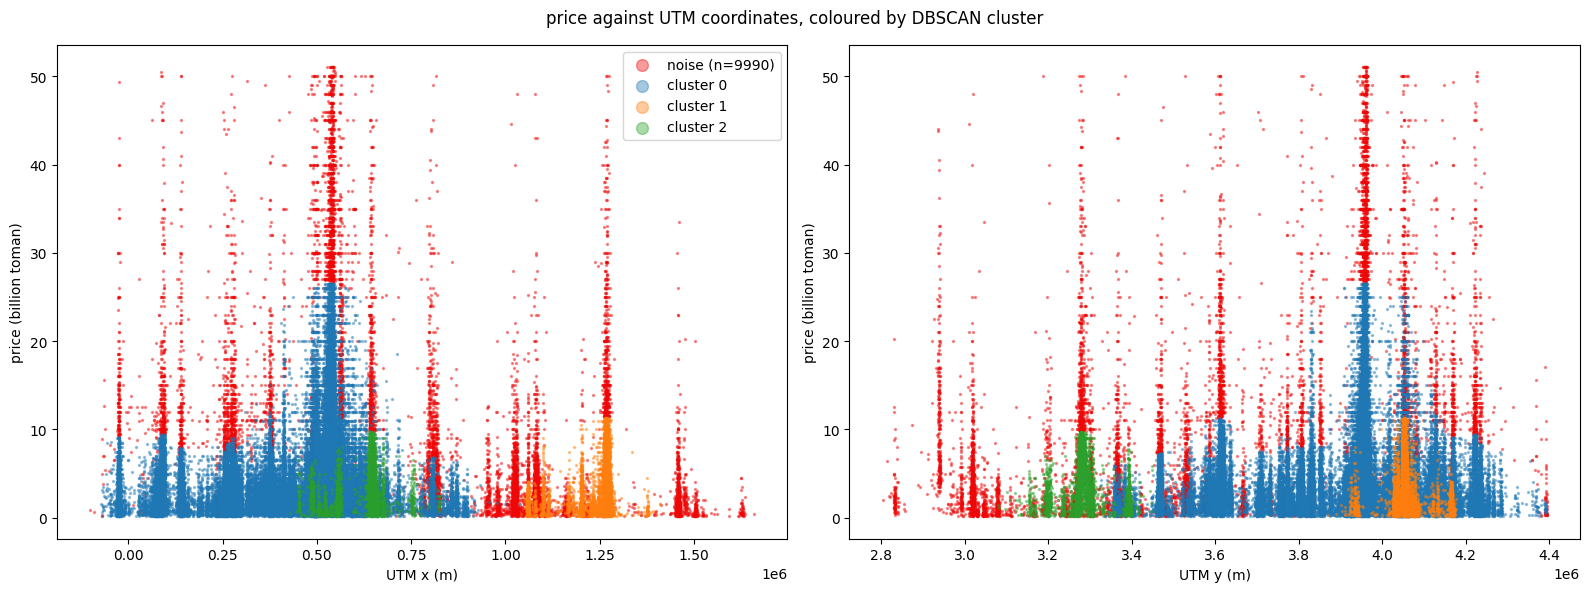

In [33]:
# dbscan price scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, coord, name in zip(axes, ['utm_x','utm_y'], ['UTM x (m)','UTM y (m)']):
    ax.scatter(data_db.loc[noise_mask, coord],data_db.loc[noise_mask,'price_value']/1e9,s=2,alpha=0.4,c='#EF0707',label=f'noise (n={noise_mask.sum()})')
    for c in sorted(data_db.loc[~noise_mask, 'dbscan'].unique()):
        sub = data_db[data_db['dbscan'] == c]
        ax.scatter(sub[coord],sub['price_value']/1e9,s=2,alpha=0.4,label=f'cluster {c}')
    ax.set_xlabel(name)
    ax.set_ylabel('price (billion toman)')

axes[0].legend(markerscale=6)
plt.suptitle('price against UTM coordinates, coloured by DBSCAN cluster')
plt.tight_layout()
plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>The same two panels as part 1, because the question asks for the DBSCAN scatter to follow part 1</li>
<li>DBSCAN has no centres, so only the points are drawn</li>
<li>The noise spreads over the whole price range, which is why its median price is three times that of the clusters</li>
</ul>
</font></div>

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>eps 0.45 with min_samples 1000 gives 3 clusters and 10% noise</li>
<li>Poles are Tehran-Karaj-Isfahan, Mashhad, Shiraz</li>
<li>Noise median is 9.2B, so much of it is luxury property</li>
<li>I ran this on a 100k sample, which the mentor accepted</li>
<li>Refitting on all 324k rows is not feasible: sklearn computes every neighbourhood at once, so at this eps the memory blows up</li>
</ul>
</font></div>